In [9]:
#CELL1 环境与配置
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import time
import random
import os
%matplotlib inline

#1.硬件与环境check
def check_environment():
    print(f"PyTorch 版本: {torch.__version__}")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"实验运行设备: {device}")
    return device

#2.设置随机种子
def set_seed(seed = 42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    #这里我的设备没有cuda可用，为了结构完整便于复现设置了一下
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

DEVICE = check_environment()
set_seed(42)

#3.实验矩阵全局配置（参考README）
CONFIG = {
    "batch_size" : 128,
    "base_lr": 0.001,
    "device": DEVICE,
    #定义的八组实验
    "experiment_matrix":[
        # Group 1: 固定学习率
        {"id": "G1-Exp1", "model_type": "MLP",       "aug": False, "scheduler": False, "epochs": 10},
        {"id": "G1-Exp2", "model_type": "LeNet5",    "aug": False, "scheduler": False, "epochs": 15},
        {"id": "G1-Exp3", "model_type": "StrongCNN", "aug": False, "scheduler": False, "epochs": 15},
        {"id": "G1-Exp4", "model_type": "StrongCNN", "aug": True,  "scheduler": False, "epochs": 15},
        
        # Group 2: 动态调整学习率（StepLR)
        {"id": "G2-Exp5", "model_type": "MLP",       "aug": False, "scheduler": True,  "epochs": 10},
        {"id": "G2-Exp6", "model_type": "LeNet5",    "aug": False, "scheduler": True,  "epochs": 15},
        {"id": "G2-Exp7", "model_type": "StrongCNN", "aug": False, "scheduler": True,  "epochs": 15},
        {"id": "G2-Exp8", "model_type": "StrongCNN", "aug": True,  "scheduler": True,  "epochs": 15},
    ]
}
print(f"\n实验矩阵已就绪,共计 {len(CONFIG['experiment_matrix'])} 组实验。")

PyTorch 版本: 2.10.0+cpu
实验运行设备: cpu

实验矩阵已就绪,共计 8 组实验。


tensor(1)
tensor(2)
tensor(8)
tensor(5)
tensor(2)


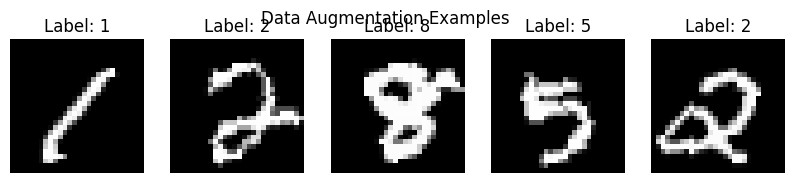

In [10]:
#CELL2 数据加载与流水线
def get_dataloader(use_augmentation=False,batch_size = 128):
    """
    根据配置获取训练集和测试集的迭代器。
    参数:
        use_augmentation: 是否开启数据增强
        batch_size: 批处理大小
    """
    #1.定义基础张量化与标准化步骤
    # MNIST 的官方均值为 0.1307，标准差为 0.3081
    base_transforms = [
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ]

    #2.数据增强的训练集变换，如果开启增强，则在基础步骤前插入随机变换
    if use_augmentation:
        #增加旋转(±15°)和平移(10%)
        #注意：数据增强的操作必须放在ToTensor之前，语义更清晰
        train_transform = transforms.Compose([
            transforms.RandomRotation(15),
            transforms.RandomAffine(degrees=0,translate=(0.1,0.1)),
            *base_transforms
        ])
    else:
        train_transform = transforms.Compose(base_transforms)

    #3.测试集变换，不加增强
    test_transform = transforms.Compose(base_transforms)

    #4.加载数据集，下载到./data目录，transform=是注册一个预处理规则，但还没执行
    train_set = torchvision.datasets.MNIST(
        root='./data', train=True, download=True, transform=train_transform
    )
    test_set = torchvision.datasets.MNIST(
        root='./data', train=False, download=True, transform=test_transform
    )

    #5.创建DataLoader，shuffle是打乱，num_workers=0是不用额外主进程加载数据
    # pin_memory=True 在有 GPU 时可以加速，只有 CPU 时设为 False 即可
    train_loader = DataLoader(
        train_set, batch_size=batch_size, shuffle=True, num_workers=0
    )
    test_loader = DataLoader(
        test_set, batch_size=1000, shuffle=False, num_workers=0
    )

    return train_loader, test_loader

#数据可视化验证
temp_loader, _ = get_dataloader(use_augmentation=True)
images, labels = next(iter(temp_loader))

plt.figure(figsize=(10, 2))
plt.suptitle("Data Augmentation Examples")
for i in range(5):
    plt.subplot(1, 5, i+1)
    # 还原归一化以便显示
    img = images[i].numpy().squeeze()
    print(labels[i])
    plt.imshow(img, cmap='gray')
    plt.title(f"Label: {labels[i]}")
    plt.axis('off')
plt.show()

In [11]:
#CELL3 模型架构的构建

#1.MLP
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()#默认从第一维开始展开(1,1,28,28)->(1,1*28*28)
        self.network = nn.Sequential(
            nn.Linear(28*28, 512),
            #先激活再正则，一是dropout可以在有效神经元里随机丢弃效率更高，二是社区惯例
            nn.ReLU(),
            nn.Dropout(0.2), # 正则化，防止过拟合
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 10)
        )
    
    def forward(self,x):
        x = self.flatten(x)
        return self.network(x)

#2.LeNet-5(现代优化版)
# 流程说明（输入为MNIST: 1x28x28）
# 1) 特征提取features:
#    Conv(1->6,k=5,p=2) -> ReLU -> MaxPool(2,2)
#    Conv(6->16,k=5)    -> ReLU -> MaxPool(2,2)
#    尺寸变化: 28x28 -> 28x28 -> 14x14 -> 10x10 -> 5x5
#    输出张量: (batch,16,5,5)
# 2) 分类头classifier:
#    Flatten -> Linear(16*5*5->120) -> ReLU
#            -> Linear(120->84)     -> ReLU
#            -> Linear(84->10)
#    前两层Linear主要用于特征重组和判别边界拉开，最后一层输出10类logits。
# 3) 为什么先ReLU再池化:
#    先激活再下采样是CNN常见顺序，通常能更稳定地保留有效响应并降低计算量。
class LeNet5(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # 输入 1x28x28，用 padding=2 确保卷积后空间尺寸保持 28x28
            # (原始 LeNet-5 论文输入是 32x32，这里为 MNIST 28x28 而适配)
            nn.Conv2d(1, 6, kernel_size=5, padding=2), 
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(6, 16, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 5 * 5, 120), 
            nn.ReLU(),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

#3.Strong CNN(VGG-style+batchnorm)
class StrongCNN(nn.Module):
    def __init__(self):
        super().__init__()
        #模块化构建：(ConV + BN + ReLU)*2 + Pool
        self.layer1 = self._make_block(1, 32)
        self.layer2 = self._make_block(32, 64)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(64 * 7 * 7, 512), # 28 -> 14 -> 7
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )

    def _make_block(self,in_channels,out_channels):
        #在工程上无论是卷积块，残差块还是transformer块重复类型都的要封装
        return nn.Sequential(
            nn.Conv2d(in_channels,out_channels,kernel_size=3,padding=1),
            #batchnorm可以对梯度的传播更平滑，抑制一部分梯度消失；在现代transformer及其变体架构里
            #一般会用layernorm和RMSNorm，只在CNN领域里batchnorm比较多
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            #对 MaxPool2d，省略 stride 时，默认用 kernel_size
            nn.MaxPool2d(2)
        )

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        return self.classifier(x)

def get_model_summary(model, name="Model"):
    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{name} 总可训练参数量: {params:,}")
    return params

# 运行预览，检查是否有架构错误
_ = get_model_summary(SimpleMLP(), "Simple MLP")
_ = get_model_summary(LeNet5(), "LeNet-5")
_ = get_model_summary(StrongCNN(), "Strong CNN")

Simple MLP 总可训练参数量: 535,818
LeNet-5 总可训练参数量: 61,706
Strong CNN 总可训练参数量: 1,676,650


In [14]:
#CELL4 训练与评估引擎

#单轮epoch训练逻辑，返回平均loss，与准确率
def train_one_epoch(model,loader,optimizer,criterion,device):
    model.train()
    running_loss  = 0.0
    correct = 0
    total = 0

    #每个batch的流程：梯度置零->前向传播->计算loss->反向传播->梯度更新
    for images,labels in loader:
        images,labels = images.to(device),labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits,labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _ , predicted = logits.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss/len(loader),correct/total

#评估逻辑
def evaluate(model,loader,criterion,device):
    model.eval()
    test_loss  = 0.0
    correct = 0
    total = 0

    #with torch.no_grad() 评估时关闭梯度计算，节省显存与时间
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
    return test_loss / len(loader), correct / total

#实验调度器，根据config自动跑完一个实验
def run_experiment(exp_config,model_class):
    print(f"\n启动实验: {exp_config['id']} | 模型: {exp_config['model_type']} | "
          f"增强: {exp_config['aug']} | 调度器: {exp_config['scheduler']}")
   
    #1.准备数据和模型
    train_loader,test_loader = get_dataloader(use_augmentation=exp_config['aug'])
    model = model_class().to(CONFIG['device'])
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(),lr = CONFIG['base_lr'])

    #2.学习率调度器设置
    scheduler = None
    if exp_config['scheduler']:
       # 每 5 个 epoch，学习率乘以 0.5 (阶梯衰减)
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    #3.记录器
    history = {'train_loss': [], 'test_acc': [], 'lrs': []}
    start_time = time.time()

    #4.训练循环
    epochs = exp_config['epochs']
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, CONFIG['device'])
        te_loss, te_acc = evaluate(model, test_loader, criterion, CONFIG['device'])
        
        current_lr = optimizer.param_groups[0]['lr']
        history['train_loss'].append(tr_loss)
        history['test_acc'].append(te_acc)
        history['lrs'].append(current_lr)

        if scheduler:
            scheduler.step()

        print(f"Epoch [{epoch:02d}/{epochs}] Loss: {tr_loss:.4f} | Acc: {te_acc:.4f} | LR: {current_lr:.5f}")
    
    duration = time.time() - start_time
    print(f"实验完成! 总耗时: {duration:.2f}s | 最终准确率: {history['test_acc'][-1]:.4f}")

    return {
        'history': history,
        'params': sum(p.numel() for p in model.parameters() if p.requires_grad),
        'duration': duration,
        'final_acc': history['test_acc'][-1]
    }


In [15]:
#CELL5 自动化运行
#建立模型名称与类的映射关系
MODEL_MAP = {
    "MLP": SimpleMLP,
    "LeNet5": LeNet5,
    "StrongCNN": StrongCNN
}

#用于存储所有实验结果的大字典
ALL_RESULTS = {}

print("开始执行 2x4 实验矩阵...")
overall_start_time = time.time()

for exp in CONFIG['experiment_matrix']:
    exp_id = exp['id']
    model_class = MODEL_MAP[exp['model_type']]
    
    #调用 Cell4 定义的引擎跑实验
    result = run_experiment(exp, model_class)
    
    #将结果存入大字典
    ALL_RESULTS[exp_id] = result

total_duration = time.time() - overall_start_time
print(f"\n所有 8 组实验全部完成！")
print(f"总运行时间: {total_duration/60:.2f} 分钟")

开始执行 2x4 实验矩阵...

启动实验: G1-Exp1 | 模型: MLP | 增强: False | 调度器: False
Epoch [01/10] Loss: 0.2583 | Acc: 0.9639 | LR: 0.00100
Epoch [02/10] Loss: 0.1100 | Acc: 0.9715 | LR: 0.00100
Epoch [03/10] Loss: 0.0812 | Acc: 0.9706 | LR: 0.00100
Epoch [04/10] Loss: 0.0628 | Acc: 0.9770 | LR: 0.00100
Epoch [05/10] Loss: 0.0573 | Acc: 0.9800 | LR: 0.00100
Epoch [06/10] Loss: 0.0478 | Acc: 0.9822 | LR: 0.00100
Epoch [07/10] Loss: 0.0413 | Acc: 0.9795 | LR: 0.00100
Epoch [08/10] Loss: 0.0387 | Acc: 0.9821 | LR: 0.00100
Epoch [09/10] Loss: 0.0339 | Acc: 0.9828 | LR: 0.00100
Epoch [10/10] Loss: 0.0332 | Acc: 0.9818 | LR: 0.00100
实验完成! 总耗时: 144.69s | 最终准确率: 0.9818

启动实验: G1-Exp2 | 模型: LeNet5 | 增强: False | 调度器: False
Epoch [01/15] Loss: 0.2833 | Acc: 0.9770 | LR: 0.00100
Epoch [02/15] Loss: 0.0782 | Acc: 0.9783 | LR: 0.00100
Epoch [03/15] Loss: 0.0564 | Acc: 0.9868 | LR: 0.00100
Epoch [04/15] Loss: 0.0444 | Acc: 0.9884 | LR: 0.00100
Epoch [05/15] Loss: 0.0360 | Acc: 0.9854 | LR: 0.00100
Epoch [06/15] Loss: 

In [ ]:
#Cell6 数据汇总表 

summary_data = []

for exp_id, res in ALL_RESULTS.items():
    # 从 exp_id 中解析信息（例如 G1-Exp1）
    group = "Fixed LR" if "G1" in exp_id else "StepLR"
    
    # 找到对应的矩阵配置
    config = next(item for item in CONFIG['experiment_matrix'] if item['id'] == exp_id)
    
    summary_data.append({
        "实验ID": exp_id,
        "模型架构": config['model_type'],
        "数据增强": "Yes" if config['aug'] else "No",
        "学习率策略": group,
        "参数量": f"{res['params']:,}",
        "训练时长(s)": round(res['duration'], 2),
        "最终准确率": f"{res['final_acc']*100:.2f}%"
    })

# 使用 Pandas 转化为 DataFrame 并显示
df = pd.DataFrame(summary_data)
# 按准确率降序排列
df_sorted = df.sort_values(by="最终准确率", ascending=False)

print("--- 实验全维度对比表 ---")
display(df_sorted)

--- 实验全维度对比表 ---


,实验ID,模型架构,数据增强,学习率策略,参数量,训练时长(s),最终准确率
7,G2-Exp8,StrongCNN,Yes,StepLR,"1,676,650",1408.61,99.63%
6,G2-Exp7,StrongCNN,No,StepLR,"1,676,650",1192.27,99.55%
2,G1-Exp3,StrongCNN,No,Fixed LR,"1,676,650",1335.72,99.46%
3,G1-Exp4,StrongCNN,Yes,Fixed LR,"1,676,650",1482.71,99.43%
5,G2-Exp6,LeNet5,No,StepLR,"61,706",274.72,98.96%
1,G1-Exp2,LeNet5,No,Fixed LR,"61,706",255.98,98.82%
4,G2-Exp5,MLP,No,StepLR,"535,818",185.42,98.35%
0,G1-Exp1,MLP,No,Fixed LR,"535,818",144.69,98.18%


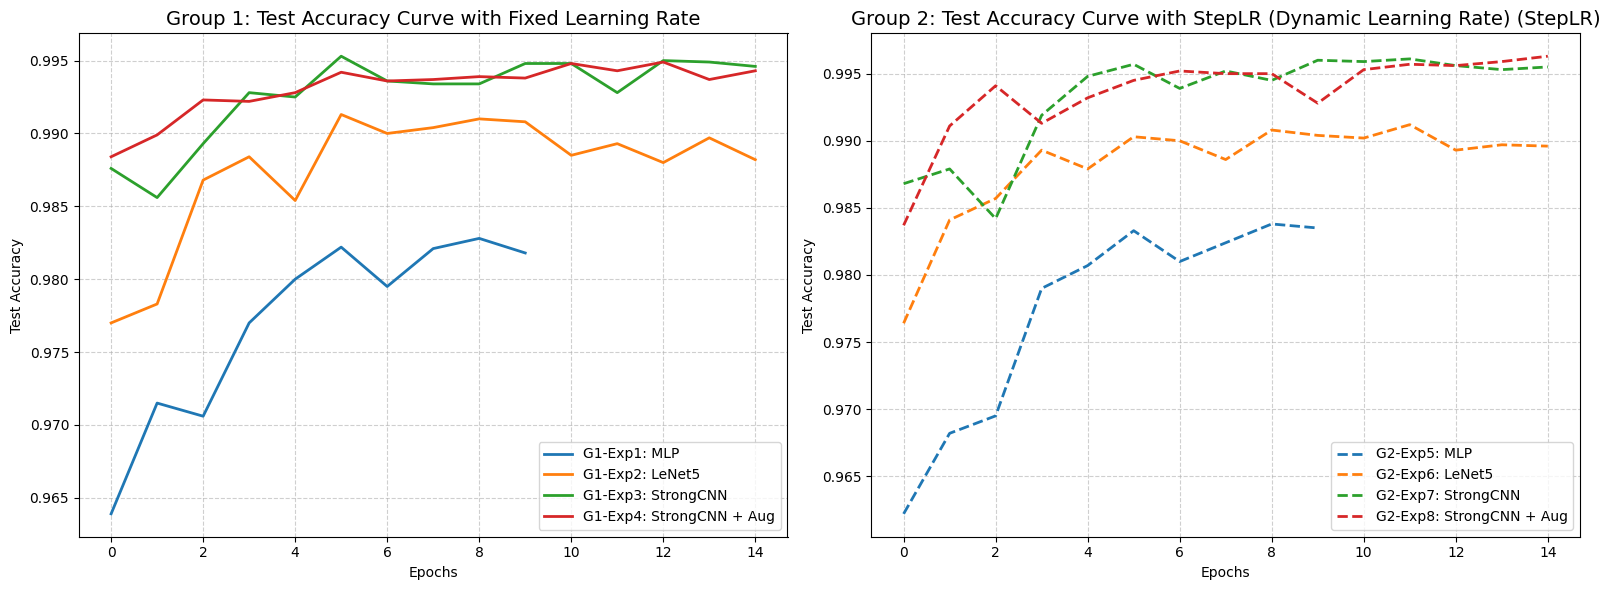

In [ ]:
#Cell7 曲线可视化 

plt.figure(figsize=(16, 6))

# --- 子图 1: Group 1 (Fixed LR) ---
plt.subplot(1, 2, 1)
for exp_id in [f"G1-Exp{i}" for i in range(1, 5)]:
    history = ALL_RESULTS[exp_id]['history']
    label = f"{exp_id}: {df.loc[df['实验ID']==exp_id, '模型架构'].values[0]}"
    if "Exp4" in exp_id: label += " + Aug"
    plt.plot(history['test_acc'], label=label, linewidth=2)

plt.title("Group 1: Test Accuracy Curve with Fixed Learning Rate", fontsize=14)
plt.xlabel("Epochs")
plt.ylabel("Test Accuracy")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# --- 子图 2: Group 2 (StepLR) ---
plt.subplot(1, 2, 2)
for exp_id in [f"G2-Exp{i}" for i in range(5, 9)]:
    history = ALL_RESULTS[exp_id]['history']
    label = f"{exp_id}: {df.loc[df['实验ID']==exp_id, '模型架构'].values[0]}"
    if "Exp8" in exp_id: label += " + Aug"
    plt.plot(history['test_acc'], label=label, linewidth=2, linestyle='--')

plt.title("Group 2: Test Accuracy Curve with StepLR (Dynamic Learning Rate) (StepLR)", fontsize=14)
plt.xlabel("Epochs")
plt.ylabel("Test Accuracy")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('learning_curves_comparison.png', dpi=300) # 保存高清图用于报告
plt.show()